In [733]:
from netgen.occ import *
from ngsolve import *
from ngsolve.webgui import Draw
import numpy as np
import time as time
import matplotlib.pyplot as plt


In [734]:
# Parameters
G = 2.55e3 # [Pa] Shear modulus
nu = 0.4 # Poisson's ratio
viscosity = 1e-3 # [N s] Fluid viscosity
alpha = 0.85 # Biot coefficient
n = 0.75 # Porosity
k = 1.131e-16 # [m^2] Intrinsic Permeability
chi = 1e-10 # [Pa^-1] Fluid Compressibility
dt = 0.01 # [s] Time step size
rho = 1000 # [kg/m^3] Fluid density
g = 9.81 # [m/s^2] Gravitational acceleration

def BulkModulus(G, nu):
    return 2*G*(1 + nu) / (3 - 6*nu)

def YoungsModulus(G, nu):
    return 2*G*(1 + nu)

def LameParameter(G, nu):
    return 2*G*nu / (1 - 2*nu)

S = n * chi + ((1-alpha)*(alpha-n)) / BulkModulus(G, nu) # Storativity 

E = YoungsModulus(G, nu) # [Pa] Young's modulus

# Parameters

L = 0.001 # [m] Characteristic length scale
L_star = 1.0 # Non-dimensional length scale
tau = L**2 * viscosity * S / k # [s] Poroelastic time scale
dt_star = dt / tau # Non-dimensional time step size

lame_star = LameParameter(G, nu) / (E) # Non-dimensional Lamé parameter
G_star = G / (E) # Non-dimensional Shear modulus
 
def Stress_star(strain):
    return 2*G_star*strain + lame_star*Trace(strain)*Id(3)

C = alpha / (E * S) # Coupling coefficient
S_star = S * E
print(E)
print(C)
print(S_star)


7140.0
94.43882533433712
0.009000535499999993


In [735]:

# Geometry

cyl = Cylinder((0, 0, 0), Y, 3.6, 1) # create a cylinder with center at (0, 0, 0), axis along Y, radius L, and height L


geo = cyl
geo.faces.name = "sides"
geo.faces.Max(Y).name = "top"
geo.faces.Min(Y).name = "bottom"
geo.faces.Max(Y).col = (1,0,0)
geo.faces.Min(Y).col = (0,0,1)

# Mesh

mesh = Mesh(OCCGeometry(cyl).GenerateMesh(maxh=0.5)).Curve(3)

# Finite element spaces

k = 2 # Polynomial order for the finite element space

V = VectorH1(mesh, order=k, dirichlet="top|bottom", dirichletx="sides", dirichletz="sides")
Q = H1(mesh,order=k-1, dirichlet="top")


(u,v) = V.TnT()
(p,q) = Q.TnT()



gfu_star = GridFunction(V)
gfp_star = GridFunction(Q)
gfp_star.Set(0)

u_old_star = GridFunction(V)
u_old_star.Set((0,0,0))

p_old_star = GridFunction(Q)
p_old_star.Set(0)
print("V.ndof =", V.ndof)
print("Q.ndof =", Q.ndof)
print('Mesh Elements = ' + str(mesh.ne))
print('Mesh Vertices = ' + str(mesh.nv))

V.ndof = 9183
Q.ndof = 507
Mesh Elements = 1633
Mesh Vertices = 507


In [ ]:
traction = 0 # Traction BC

tbar = CoefficientFunction((0, traction, 0))
b = CoefficientFunction((0, -rho*g , 0)) # Body force

qbar = CoefficientFunction(0) # Flux BC

# K* (Stiffness) - Dimensionless
a_K = BilinearForm(V)
a_K += InnerProduct(Sym(Grad(u)), Stress_star(Sym(Grad(v)))) * dx
pre_a_K = Preconditioner(a_K, type="h1amg")
a_K.Assemble()

# Q* (Coupling) - Note: alpha is often kept here or used as a multiplier
# Q* corresponds to the integral of div(u)*p
a_Q12 = BilinearForm(trialspace=Q,testspace=V)
a_Q12 += p * div(v) * dx
a_Q12.Assemble()

a_Q21 = BilinearForm(trialspace=V,testspace=Q)
a_Q21 += q * div(u) * dx
a_Q21.Assemble()

# S* (Storage) - Pure L2 mass matrix
a_S = BilinearForm(Q)
a_S += p * q * dx
pre_a_S = Preconditioner(a_S, type="local")
a_S.Assemble()

# H* (Conductivity) - Pure Laplacian
a_H = BilinearForm(Q)
a_H += InnerProduct(Grad(p), Grad(q)) * dx
pre_a_H = Preconditioner(a_H, type="local")
a_H.Assemble()

# Preconditioner for Displacement
a_PreP = BilinearForm(Q)
a_PreP += (Grad(p) * Grad(q) + p * q) * dx
pre_a_P = Preconditioner(a_PreP, type="h1amg") # Use AMG for the pressure too
a_PreP.Assemble()

# Normalize traction and body forces
tbar_star = tbar / E
b_star = (b * L) / E

b_f = LinearForm(V)
b_f += (v * tbar_star) * ds("top") + (v * b_star) * dx
b_f.Assemble()

# qbar usually represents flux, scale appropriately
qbar_star = (qbar * L) / (viscosity * E) 
b_q = LinearForm(Q)
b_q += qbar_star * q * ds("top")
b_q.Assemble()

print('K =',a_K.mat.shape)
print('Q12 =',a_Q12.mat.shape)
print('Q21 =',a_Q21.mat.shape)
print('S =',a_S.mat.shape)
print('H =',a_H.mat.shape)

print('f =',b_f.vec.size)
print('q =',b_q.vec.size)
print('u =',u_old_star.vec.size)
print('p =',p_old_star.vec.size)

K = (9183, 9183)
Q12 = (9183, 507)
Q21 = (507, 9183)
S = (507, 507)
H = (507, 507)
f = 9183
q = 507
u = 9183
p = 507


In [737]:
ea = {"euler_angles": [20, 5, 0]}
scene_u = Draw(-gfu_star*L*1000,mesh, deformation=gfu_star, **ea)
scene_p = Draw(gfp_star * E,mesh, deformation=gfu_star, **ea)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

In [738]:

from ngsolve.krylovspace import GMRes

time_vals_nondim, p_min_nondim, p_max_nondim, F_solid, F_fluid = [], [], [], [], []
t = 0
t_end = 300 # [s] End time

t_end_star = t_end / tau
u_max = 1e-4 # [m] Maximum displacement


u_max_star = u_max / L
t_ramp = 10 # [s] Time to reach full load
t_ramp_star = t_ramp / tau


# 1. Define the normal vector and vertical direction
n = specialcf.normal(mesh.dim)
vertical = CF((0, 1, 0)) # Upward direction

growth_factor = 1.1 # time step grownt factor for dynamic time stepping
dt_star_max = 50.0 / tau # Set a reasonable upper limit for your physical scaled time step size


# 2. Assemble the Matrices and Preconditioner (As you did)
# Note: Ensure preconditioners use "direct" or "local" inverse types internally




A = BlockMatrix([
    [a_K.mat,        -alpha * a_Q12.mat],
    [C * a_Q21.mat,   dt_star * a_H.mat + S_star * a_S.mat]
])

F = BlockVector([
    b_f.vec, 
    C * a_Q21.mat * u_old_star.vec + S_star * a_S.mat * p_old_star.vec + dt_star * b_q.vec
])

# Create the Block solution vector (linking to your GridFunctions)
sol = BlockVector([gfu_star.vec, gfp_star.vec])

# Pre-allocate memory for the residual and correction to avoid recreation
rhs_resid = F.CreateVector()
correction = F.CreateVector()

# 1. Calculate the total vertical reaction force on the bottom
# Create a mask for the bottom boundary nodes
bottom_dofs = V.GetDofs(mesh.Boundaries("bottom"))

# This is for solid force
v_test = GridFunction(V)
v_test.Set(CF((0, 1, 0)), definedon=mesh.Boundaries("bottom")) 
# Before the loop, ensure u_old and p_old are initialized to zero (or initial state)

while t < t_end_star:
    t += dt_star
    print(f"Time: {t*tau:.4f} s / {t_end:.4f} s", end='\r')
    uy_star = min(t / t_ramp_star, 1.0) * u_max_star
    disp_cf_star = CF((0, -uy_star, 0))
    gfu_star.Set(disp_cf_star, definedon=mesh.Boundaries("top"))
    # 1. Update the RHS (F) FIRST using the state from the END of the previous step
    # This ensures the 'source' for pressure is based on the previous equilibrium

    A = BlockMatrix([
    [a_K.mat,        -alpha * a_Q12.mat],
    [C * a_Q21.mat,   dt_star * a_H.mat + S_star * a_S.mat]
    ])
    #F[0].data = b_f.vec
    F[1].data = (C * a_Q21.mat * u_old_star.vec + 
                 S_star * a_S.mat * p_old_star.vec + 
                 dt_star * b_q.vec)

    pre_C = BlockMatrix([
    [pre_a_K, None],
    [None, dt_star * pre_a_P]
])
    

    # 3. Synchronize the 'sol' BlockVector
    sol[0].data = gfu_star.vec
    sol[1].data = gfp_star.vec

    # 4. Calculate the residual
    # Since sol[0] has the new BC and F[1] has the old state, 
    # the solver correctly identifies the 'change' over dt.
    rhs_resid.data = F - A * sol

    ################################
    fluid_force_star = Integrate(gfp_star, mesh, definedon=mesh.Boundaries("bottom"))
    F_fluid.append(fluid_force_star)

    fluid_force_phys = fluid_force_star * (E * L**2)


    ################################
    
    rhs_resid[0].data[~V.FreeDofs()] = 0.0
    rhs_resid[1].data[~Q.FreeDofs()] = 0.0

    Rp = rhs_resid[1].Norm()
    bp = F[1].Norm()

    #print("Relative pressure residual:", Rp / bp if bp > 0 else 0)
    # 5. Solve and update
    correction[:] = 0.0
    GMRes(A=A, b=rhs_resid, pre=pre_C, x=correction, tol=1e-10, printrates=False, maxsteps=50)
    sol.data += correction


    sigma_star = Stress_star(Sym(Grad(gfu_star)))
    
    # Use the Virtual Work method to get the dimensionless force
    # Note: v_test only needs to be defined once outside the loop
    solid_force_star = Integrate(InnerProduct(sigma_star, Grad(v_test)), mesh)
    
    # Unscale and store
    solid_force_phys = solid_force_star * (E * L**2)
    F_solid.append(solid_force_phys)


    print(f"Solid: {solid_force_phys:.6f}, Fluid: {fluid_force_phys:.6f}, Total: {solid_force_phys + fluid_force_phys:.6f}, \
          Time: {t*tau:.4f} s / {t_end:.4f} s, dt: {dt_star * tau:.6f} s")


    F_solid.append(solid_force_phys)
    F_fluid.append(fluid_force_phys)
    #
    # 6. Handover (Update history for next step)
    u_old_star.vec.data = gfu_star.vec
    p_old_star.vec.data = gfp_star.vec

    pmin = np.min(gfp_star.vec.FV().NumPy())
    pmax = np.max(gfp_star.vec.FV().NumPy())

    p_min_nondim.append(pmin)
    p_max_nondim.append(pmax)
    time_vals_nondim.append(t)
    # Update the visualization
    
    scene_u.Redraw()
    scene_p.Redraw()
    dt_star = min(dt_star * growth_factor, dt_star_max)

 

Solid: -0.000026, Fluid: 0.000000, Total: -0.000026,           Time: 0.0100 s / 300.0000 s, dt: 0.010000 s
Solid: -0.000055, Fluid: 0.000906, Total: 0.000852,           Time: 0.0210 s / 300.0000 s, dt: 0.011000 s
Solid: -0.000086, Fluid: 0.001388, Total: 0.001302,           Time: 0.0331 s / 300.0000 s, dt: 0.012100 s
Solid: -0.000120, Fluid: 0.001918, Total: 0.001798,           Time: 0.0464 s / 300.0000 s, dt: 0.013310 s
Solid: -0.000158, Fluid: 0.002501, Total: 0.002343,           Time: 0.0611 s / 300.0000 s, dt: 0.014641 s
Solid: -0.000200, Fluid: 0.003142, Total: 0.002942,           Time: 0.0772 s / 300.0000 s, dt: 0.016105 s
Solid: -0.000246, Fluid: 0.003847, Total: 0.003601,           Time: 0.0949 s / 300.0000 s, dt: 0.017716 s
Solid: -0.000296, Fluid: 0.004622, Total: 0.004326,           Time: 0.1144 s / 300.0000 s, dt: 0.019487 s
Solid: -0.000351, Fluid: 0.005474, Total: 0.005123,           Time: 0.1358 s / 300.0000 s, dt: 0.021436 s
Solid: -0.000412, Fluid: 0.006410, Total: 0.0

[0.0, 0.0, 0.1269123658658206, 0.0009061542922819591, 0.1944035401268289, 0.0013880412765055583, 0.26863775911746535, 0.0019180736000987025, 0.3502764738013236, 0.0025009740229414504, 0.4400532897417252, 0.0031419804887559176, 0.5387699992069933, 0.003846817794337932, 0.6473069985472683, 0.004621771969627495, 0.7666322502644425, 0.005473754266888119, 0.8978092542155187, 0.006410358075098804, 1.042005859704243, 0.007439921838288294, 1.200505065501209, 0.008571606167678632, 1.374720596713437, 0.00981550506053394, 1.5662221150987812, 0.011182825901805298, 1.7767483019236088, 0.012685982875734567, 2.0081537428915524, 0.014338217724245683, 2.2624204114703055, 0.016153681737897982, 2.5417360431432874, 0.01814799534804307, 2.848514191020736, 0.020338391323888053, 3.1854028012206803, 0.022743776000715657, 3.5553064414734643, 0.025384887992120533, 3.9614219644500683, 0.028284552826173485, 4.407224822190646, 0.03146758523044121, 4.896421580375248, 0.03496045008387927, 5.433050660065963, 0.038791

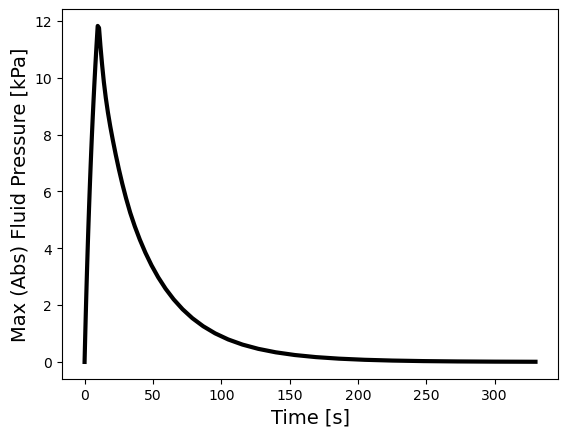

In [739]:
p_max = np.array(p_max_nondim)*E
p_min = np.array(p_min_nondim)*E
t_vals = np.array(time_vals_nondim)*tau
Ff = np.array(F_fluid)
Fs = np.array(F_solid)

print(F_fluid)
p_max = np.insert(p_max, 0, 0.0)
p_min = np.insert(p_min, 0, 0.0)
t_vals = np.insert(t_vals, 0, 0.0)
plt.plot(t_vals, np.abs(p_max)/1000, lw=3, color='black')
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Max (Abs) Fluid Pressure [kPa]', fontsize=14)
#plt.savefig('fluid_pressure_vs_time.png', dpi=300)
plt.show()

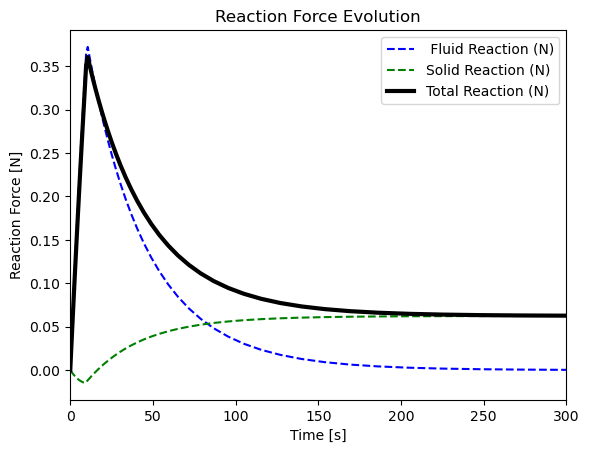

In [742]:
# Assuming 'data' is your list of mixed values

fluid_forces = F_fluid[1::2] # Starts at 1, jumps by 2
#solid_forces = F_solid[0::2] # Starts at 0, jumps by 2
solid_forces = F_solid[::2] # Starts at 0, jumps by 2
total_forces = np.array(fluid_forces) + np.array(solid_forces)
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

ax1.plot(t_vals[:-1], fluid_forces, 'b--', label=' Fluid Reaction (N)')


ax1.plot(t_vals[:-1], solid_forces, 'g--', label='Solid Reaction (N)')

ax1.plot(t_vals[:-1], total_forces, 'black',lw=3 , label='Total Reaction (N)')
ax1.set(xlabel='Time [s]', ylabel='Reaction Force [N]')
ax1.legend(loc='upper right')
plt.title("Reaction Force Evolution")
plt.xlim(0,300)
plt.show()

In [741]:
def Stress(strain):
    return 2*G*strain + LameParameter(G, nu)*Trace(strain)*Id(3)

#modulus of sigma . n


with TaskManager():
    fesstress = MatrixValued(H1(mesh,order=3), symmetric=True)
    gfstress = GridFunction(fesstress)

    
    # Apply the gradient to the GridFunction first, then scale the result
    #gfstress.Interpolate(Stress(Sym(Grad(gfu))))

    # 1. Define the stress using the correct dimensionless parameters
    # Use the unscaled GridFunction for the Gradient
    sigma_star = Stress_star(Sym(Grad(gfu_star)))

    # 2. Interpolate into your stress GridFunction i 
    # f needed for visualization
    gfstress.Interpolate(sigma_star*E)




Draw (Norm(gfstress), mesh, draw_vol=False, order=3)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene